# Exploratory Data Analysis
This notebook checks class balance, image sizes, sample photos, pixel values, and data augmentation.

## 1. Setup


In [32]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from PIL import Image
from tensorflow.keras import layers

random.seed(42)
sns.set_theme(style="whitegrid")

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Data Path

Images are in `data/`, split into `train` and `test`. Each split has `cats` and `dogs`.

In [33]:
DATA_DIR = Path("..") / "data"
REPORTS_DIR = Path("..") / "reports" / "figures"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

def list_images(folder):
    return sorted(
        path for path in Path(folder).iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTS
    )

print("Data folder:", DATA_DIR.resolve())
print("Exists:", DATA_DIR.exists())
print("Reports folder:", REPORTS_DIR.resolve())

Data folder: /media/ashish/c287b5fb-f7e6-40ae-be97-12df427f3339/ai/cnn-image-classifier/data
Exists: True


## 3. Class Balance
Count images per class. Balanced classes make training more reliable.

Dataset Class  Count
  Train  Cats  10000
  Train  Dogs  10000
   Test  Cats   2500
   Test  Dogs   2500

Train total: 20000
Test total:  5000


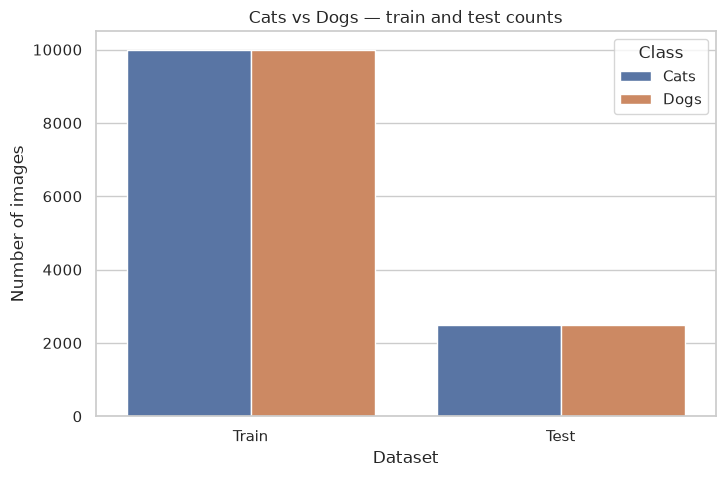

In [34]:
cat_train = len(list_images(DATA_DIR / "train" / "cats"))
dog_train = len(list_images(DATA_DIR / "train" / "dogs"))
cat_test = len(list_images(DATA_DIR / "test" / "cats"))
dog_test = len(list_images(DATA_DIR / "test" / "dogs"))

counts = pd.DataFrame({
    "Dataset": ["Train", "Train", "Test", "Test"],
    "Class": ["Cats", "Dogs", "Cats", "Dogs"],
    "Count": [cat_train, dog_train, cat_test, dog_test],
})

print(counts.to_string(index=False))
print(f"\nTrain total: {cat_train + dog_train}")
print(f"Test total:  {cat_test + dog_test}")

plt.figure(figsize=(8, 5))
sns.barplot(data=counts, x="Dataset", y="Count", hue="Class")
plt.title("Cats vs Dogs — train and test counts")
plt.ylabel("Number of images")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "class_balance.png", dpi=120, bbox_inches="tight")
plt.show()

## 4. Image Sizes

CNNs need a fixed input size. These plots show how much width and height vary in the training set.

In [35]:
def image_sizes(folder):
    sizes = []
    for path in list_images(folder):
        with Image.open(path) as img:
            sizes.append(img.size)  # (width, height)
    return sizes

Images checked: 20000
         Width   Height
count  20000.0  20000.0
mean     404.0    360.1
std      109.0     97.1
min       42.0     33.0
25%      321.0    301.0
50%      447.0    374.0
75%      499.0    419.0
max     1023.0    768.0


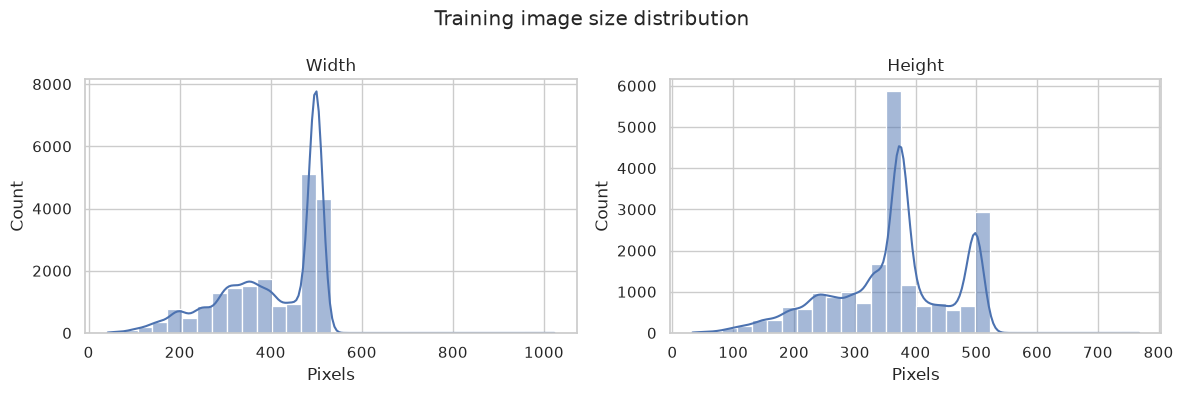

In [36]:
cat_sizes = image_sizes(DATA_DIR / "train" / "cats")
dog_sizes = image_sizes(DATA_DIR / "train" / "dogs")

df_sizes = pd.DataFrame(cat_sizes + dog_sizes, columns=["Width", "Height"])

print(f"Images checked: {len(df_sizes)}")
print(df_sizes.describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df_sizes, x="Width", bins=30, kde=True, ax=axes[0])
axes[0].set_title("Width")
axes[0].set_xlabel("Pixels")

sns.histplot(data=df_sizes, x="Height", bins=30, kde=True, ax=axes[1])
axes[1].set_title("Height")
axes[1].set_xlabel("Pixels")

plt.suptitle("Training image size distribution")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "image_sizes.png", dpi=120, bbox_inches="tight")
plt.show()

## 5. Sample Images

Look at a few training images to check labels, crop, and quality.

In [37]:
def show_sample_grid(folder, title, n=6, save_path=None):
    files = list_images(folder)
    files = random.sample(files, min(n, len(files)))

    plt.figure(figsize=(12, 3))
    for i, path in enumerate(files):
        img = Image.open(path)
        plt.subplot(1, len(files), i + 1)
        plt.imshow(img)
        plt.title(f"{img.size[0]}×{img.size[1]}", fontsize=9)
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()

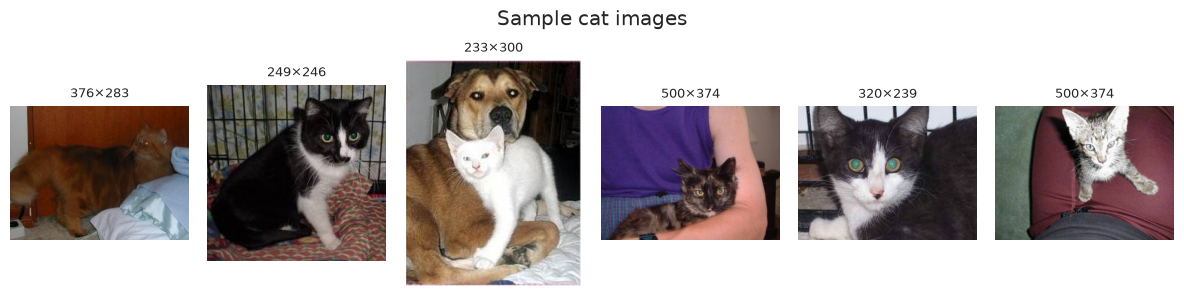

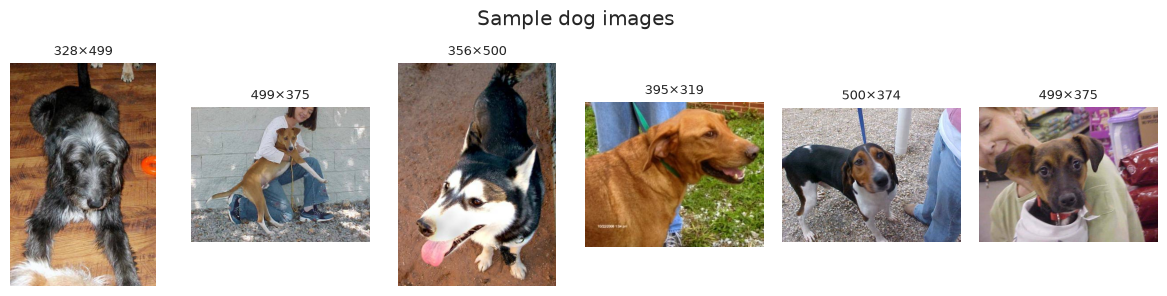

In [38]:
show_sample_grid(
    DATA_DIR / "train" / "cats",
    "Sample cat images",
    save_path=REPORTS_DIR / "sample_cats.png",
)
show_sample_grid(
    DATA_DIR / "train" / "dogs",
    "Sample dog images",
    save_path=REPORTS_DIR / "sample_dogs.png",
)

## 6. Pixel Intensity

Compare brightness of cat vs dog images. Values should stay in 0–255 before we rescale them for the model.

In [39]:
def sample_pixel_values(folder, n=100, size=(100, 100)):
    files = list_images(folder)
    files = random.sample(files, min(n, len(files)))

    pixels = []
    for path in files:
        img = Image.open(path).convert("RGB").resize(size)
        pixels.append(np.array(img).ravel())

    return np.concatenate(pixels)

Cats  min=0  max=255  mean=112.5
Dogs  min=0  max=255  mean=116.2


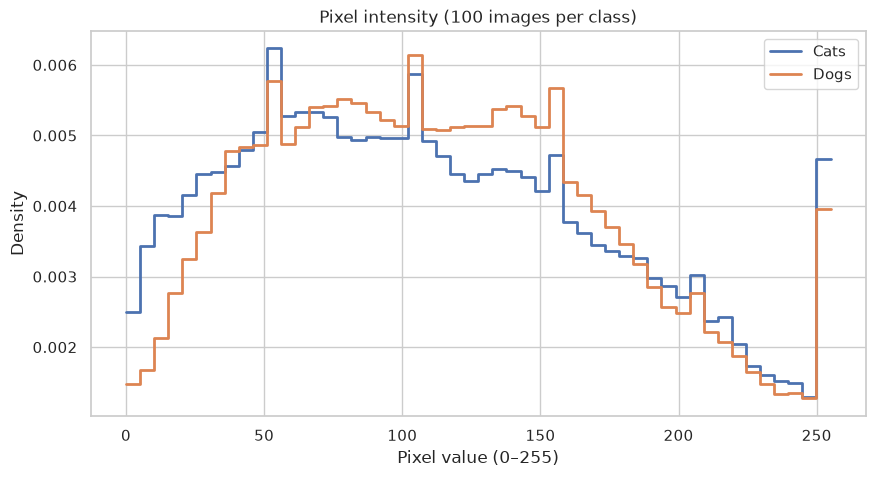

In [40]:
cat_pixels = sample_pixel_values(DATA_DIR / "train" / "cats")
dog_pixels = sample_pixel_values(DATA_DIR / "train" / "dogs")

def pixel_stats(name, values):
    print(f"{name:4}  min={values.min()}  max={values.max()}  mean={values.mean():.1f}")

pixel_stats("Cats", cat_pixels)
pixel_stats("Dogs", dog_pixels)

plt.figure(figsize=(10, 5))
sns.histplot(cat_pixels, bins=50, stat="density", element="step", fill=False, linewidth=2, label="Cats")
sns.histplot(dog_pixels, bins=50, stat="density", element="step", fill=False, linewidth=2, label="Dogs")
plt.title("Pixel intensity (100 images per class)")
plt.xlabel("Pixel value (0–255)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig(REPORTS_DIR / "pixel_intensity.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Data Augmentation

Preview Keras augmentations. These add variety so the model is less likely to overfit.

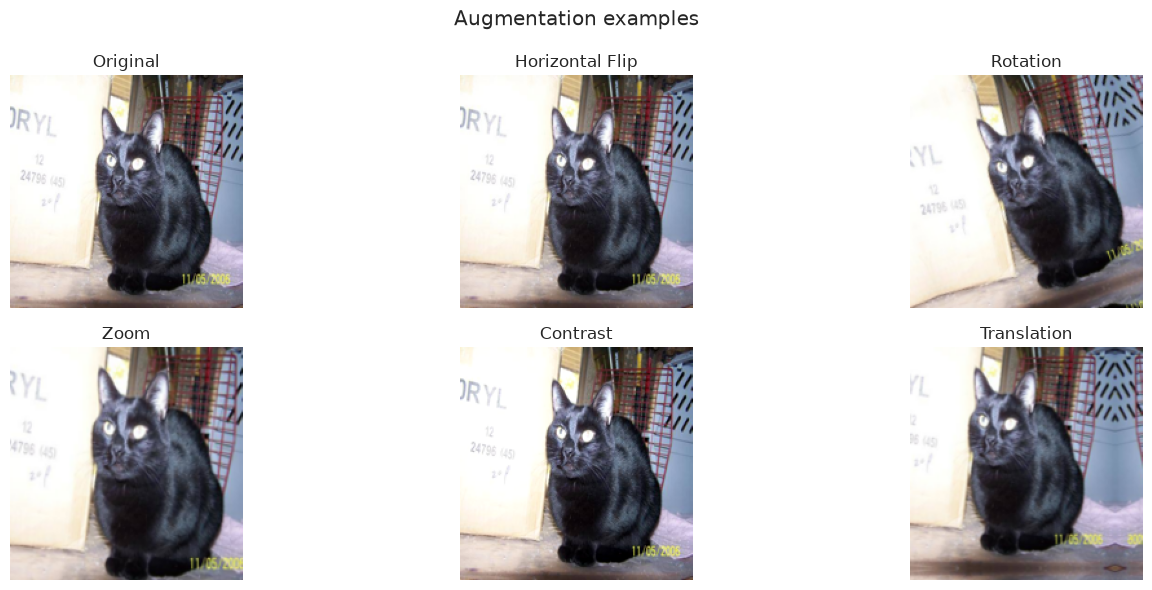

In [41]:
sample_path = list_images(DATA_DIR / "train" / "cats")[5]
sample_img = Image.open(sample_path).convert("RGB").resize((180, 180))
sample_arr = np.expand_dims(np.array(sample_img), axis=0).astype("float32")

augmentations = {
    "Original": None,
    "Horizontal Flip": layers.RandomFlip("horizontal"),
    "Rotation": layers.RandomRotation(0.15),
    "Zoom": layers.RandomZoom(0.15),
    "Contrast": layers.RandomContrast(0.15),
    "Translation": layers.RandomTranslation(0.15, 0.15),
}

plt.figure(figsize=(15, 6))
for i, (name, layer) in enumerate(augmentations.items()):
    if layer is None:
        img_to_show = sample_arr[0]
    else:
        img_to_show = layer(sample_arr, training=True)[0].numpy()

    img_to_show = np.clip(img_to_show, 0, 255).astype("uint8")
    plt.subplot(2, 3, i + 1)
    plt.imshow(img_to_show)
    plt.title(name)
    plt.axis("off")

plt.suptitle("Augmentation examples")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "augmentation.png", dpi=120, bbox_inches="tight")
plt.show()